<a href="https://colab.research.google.com/github/Siam19-ai/MachineLearning/blob/main/Forecasting(Normal%20linear%20regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!git clone https://github.com/Siam19-ai/MachineLearning.git

Cloning into 'MachineLearning'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 26 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 94.22 KiB | 6.73 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import sklearn

In [28]:
df=pd.read_csv("/content/MachineLearning/Food Delivery Dataset.csv")

In [29]:
df['new_created_at'] = pd.to_datetime(df['created_at'])
df['new_actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

/tmp/ipykernel_484/3261693086.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['new_created_at'] = pd.to_datetime(df['created_at'])
/tmp/ipykernel_484/3261693086.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['new_actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])


In [30]:
df.isnull().sum()

,0
market_id,3
store_primary_category,26
order_protocol,3
total_items,0
subtotal,0
min_item_price,0
max_item_price,0
total_onshift_partners,80
total_busy_partners,80
total_outstanding_orders,80


In [32]:
df = df.sort_values('new_created_at').reset_index(drop=True)
df['delivery_time_minutes'] = (
    (df['new_actual_delivery_time'] - df['new_created_at'])
    .dt.total_seconds() / 60
)

# Calculate how much data we are losing
initial_count = len(df)
df = df[df["delivery_time_minutes"] >= 0]
deleted_count = initial_count - len(df)

print(f"Removed {deleted_count} rows ({deleted_count/initial_count:.2%}) due to negative delivery times.")

# Standard Academic Outlier Removal (Upper Bound)
Q1 = df["delivery_time_minutes"].quantile(0.25)
Q3 = df["delivery_time_minutes"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Filtering extreme high-end outliers
df = df[df["delivery_time_minutes"] <= upper_bound]

Removed 38 rows (3.80%) due to negative delivery times.


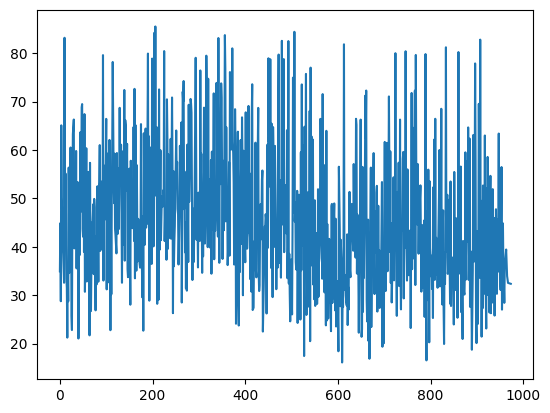

In [35]:
plt.plot(df["delivery_time_minutes"], linestyle ="solid")
plt.show()

ADF Statistic: -3.199
p-value: 0.020
Result: Data is Stationary (Good for ARIMA)


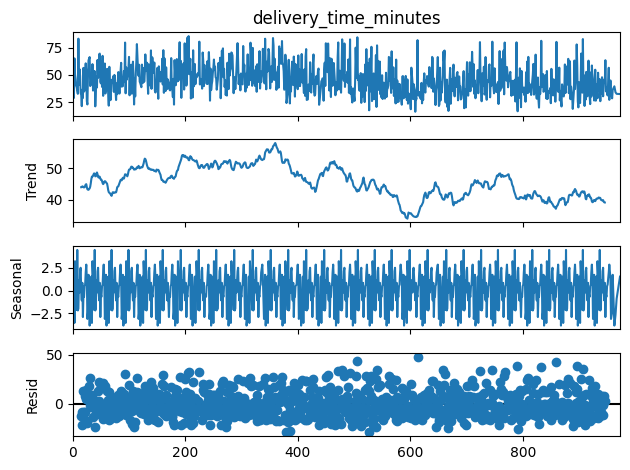

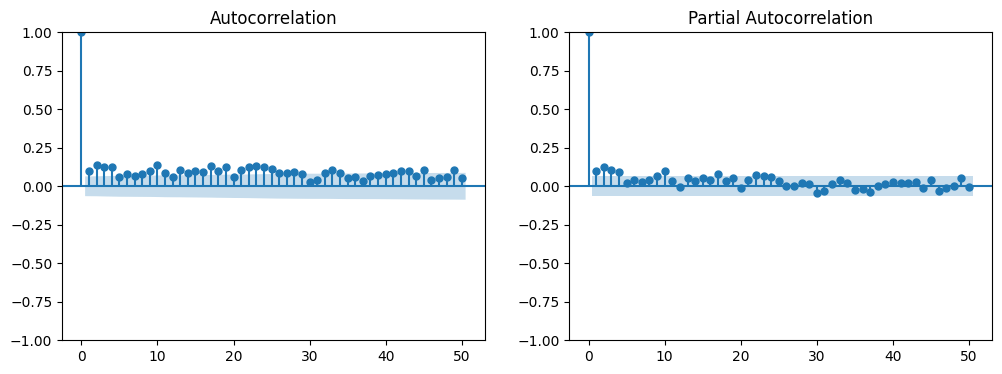

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def check_stationarity(data):
    result = adfuller(data)
    print(f'ADF Statistic: {result[0]:.3f}')
    print(f'p-value: {result[1]:.3f}')
    if result[1] <= 0.05:
        print("Result: Data is Stationary (Good for ARIMA)")
    else:
        print("Result: Data is Non-Stationary (Needs Differencing)")

check_stationarity(df["delivery_time_minutes"])

decomposition = seasonal_decompose(df["delivery_time_minutes"], model='additive', period=30)
decomposition.plot()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df["delivery_time_minutes"], lags=50, ax=ax1)
plot_pacf(df["delivery_time_minutes"], lags=50, ax=ax2)
plt.show()

In [37]:
df["delivery_time_minutes"].index

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       953, 954, 956, 957, 959, 960, 963, 965, 967, 973],
      dtype='int64', length=933)

**FORECASTING**

In [38]:
y=df["delivery_time_minutes"]

In [39]:
features = [
    "total_items",
    "subtotal",
    "min_item_price",
    "max_item_price",
    "total_onshift_partners",
    "total_busy_partners",
    "total_outstanding_orders",
    "created_day",
    "created_holiday"
]

X = df[features]

print(X)

     total_items  subtotal  min_item_price  max_item_price  \
0              7      9208             679            1679   
1              4      2040             142             813   
2              4      1690             295             795   
3              7      4200             350            1050   
4              2      1850             650             850   
..           ...       ...             ...             ...   
960            2      1399             499             900   
963            1      2015            1425            1425   
965            2      2998            1499            1499   
967            4      3530             695             795   
973            2      1500             400            1100   

     total_onshift_partners  total_busy_partners  total_outstanding_orders  \
0                      63.0                 45.0                      49.0   
1                      15.0                 14.0                      17.0   
2                    

In [40]:
df_model = df[features + ["delivery_time_minutes"]].dropna()

X = df_model[features]
y = df_model["delivery_time_minutes"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Identify categorical columns
categorical_features = ["created_day", "created_holiday"]

# Apply one-hot encoding to X_train and X_test
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

model = LinearRegression()
model.fit(X_train_encoded, y_train)

LinearRegression()

In [47]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test_encoded)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R²: 0.13975748363133378
MAE: 8.975972989197404
